In [315]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [316]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [317]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available else "cpu"

device

'cuda'

In [318]:
df = pd.read_csv('filtered_data.csv')
df.dropna(axis=0, inplace=True)

In [319]:
df.columns.tolist()

['Attendance',
 'Hours_Studied',
 'Support_Multiplier',
 'Overcoming_Odds',
 'Disadvantage_Score',
 'Tutoring_Sessions',
 'Motivation_Sustainability',
 'Access_to_Resources',
 'Parental_Education_Level',
 'Previous_Scores',
 'Inefficiency_Flag',
 'Teacher_Quality',
 'Motivation_Level',
 'Effort_Payoff',
 'Family_Income',
 'Sleep_Hours',
 'Physical_Activity',
 'Peer_Influence',
 'Support_Index',
 'Resilience_Score',
 'Exam_Score']

In [320]:
X = df.drop("Exam_Score", axis=1)
y = df['Exam_Score']

In [321]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [322]:
numerical_cols = [
    'Attendance', 'Hours_Studied', 'Support_Multiplier', 'Overcoming_Odds',
    'Disadvantage_Score', 'Tutoring_Sessions', 'Motivation_Sustainability',
    'Previous_Scores', 'Effort_Payoff', 'Sleep_Hours', 'Physical_Activity',
    'Support_Index', 'Resilience_Score'
]

ordinal_cols = [
    'Access_to_Resources', 'Teacher_Quality', 'Motivation_Level',
    'Family_Income', 'Peer_Influence', 'Parental_Education_Level'
]

ordinal_categories = [
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Low', 'Medium', 'High'],
    ['Negative', 'Neutral', 'Positive'],
    ['High School', 'College', 'Postgraduate']
]

nominal_cols = ['Inefficiency_Flag']

In [323]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("ord", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1), ordinal_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

In [ ]:
y_train_original_data = y_train.copy()
y_val_original_data = y_val.copy()
y_test_original_data = y_test.copy()

scaler = StandardScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val = scaler.transform(y_val.values.reshape(-1, 1))
y_test = scaler.transform(y_test.values.reshape(-1, 1))   

In [325]:
class StudentDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y.values).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [326]:
train_data = StudentDataset(X_train, pd.Series(y_train.flatten()))
val_data = StudentDataset(X_val, pd.Series(y_val.flatten()))
test_data = StudentDataset(X_test, pd.Series(y_test.flatten()))

print(f"train size: {len(train_data)}, val size: {len(val_data)}, test size: {len(test_data)}")

train size: 4181, val size: 1031, test size: 1289


In [327]:
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"number of batches in training: {len(train_loader)}, validating: {len(val_loader)} and testing: {len(test_loader)}")

number of batches in training: 66, validating: 17 and testing: 21


In [328]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(21, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.flatten(x)
        result = self.linear_relu_stack(x)
        return result

In [329]:
model = NeuralNetwork().to(device)
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=21, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [330]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [331]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()

    for batch, (X,  y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)

        y_original = scaler.inverse_transform(y.detach().cpu().numpy())
        
        weights = torch.zeros_like(y)
        for i in range(len(y)):
            if y_original[i] > 85:
                weights[i] = 10.0
            elif y_original[i] > 75:
                weights[i] = 2.0
            else:
                weights[i] = 1.0
        
        weights = weights.to(device)

        loss = loss_fn(pred, y)

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [332]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())

    test_loss /= num_batches
    
    predictions = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    
    print(f"Test Metrics:")
    print(f"  MSE Loss: {test_loss:>8f}")
    print(f"  MAE: {mae:>8f}")
    print(f"  RMSE: {rmse:>8f}")
    print(f"  R² Score: {r2:>8f}\n")

In [333]:
epochs = 2000
for t in range(epochs):
    if (t+1) % 100 == 0:
        print(f"Epoch {t+1}\n {"-"*30}")
        train(train_loader, model, loss_fn, optimizer)
        test(test_loader, model, loss_fn)

Epoch 100
 ------------------------------
loss: 7.473594  [   64/ 4181]
Test Metrics:
  MSE Loss: 0.944670
  MAE: 0.759924
  RMSE: 0.983693
  R² Score: -0.021275

Epoch 200
 ------------------------------
loss: 4.464314  [   64/ 4181]
Test Metrics:
  MSE Loss: 1.129484
  MAE: 0.794891
  RMSE: 1.064160
  R² Score: -0.195191

Epoch 300
 ------------------------------
loss: 5.575614  [   64/ 4181]
Test Metrics:
  MSE Loss: 1.133213
  MAE: 0.779397
  RMSE: 1.064157
  R² Score: -0.195186

Epoch 400
 ------------------------------
loss: 5.503500  [   64/ 4181]
Test Metrics:
  MSE Loss: 1.275374
  MAE: 0.714235
  RMSE: 1.139991
  R² Score: -0.371596

Epoch 500
 ------------------------------
loss: 2.944477  [   64/ 4181]
Test Metrics:
  MSE Loss: 1.079382
  MAE: 0.686396
  RMSE: 1.037292
  R² Score: -0.135600

Epoch 600
 ------------------------------
loss: 6.628185  [   64/ 4181]
Test Metrics:
  MSE Loss: 1.103502
  MAE: 0.691370
  RMSE: 1.048383
  R² Score: -0.160015

Epoch 700
 -----------

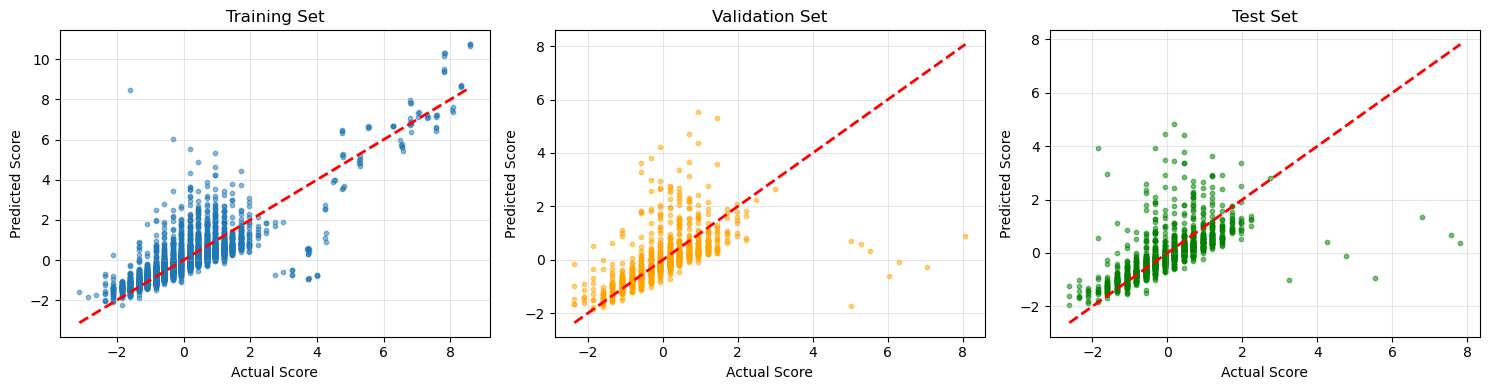

In [334]:
model.eval()
with torch.no_grad():
    train_pred = model(torch.FloatTensor(X_train).to(device)).cpu().numpy()
    val_pred = model(torch.FloatTensor(X_val).to(device)).cpu().numpy()
    test_pred = model(torch.FloatTensor(X_test).to(device)).cpu().numpy()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_train.flatten(), train_pred, alpha=0.5, s=10)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title('Training Set')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val.flatten(), val_pred, alpha=0.5, s=10, color='orange')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')
axes[1].set_title('Validation Set')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test.flatten(), test_pred, alpha=0.5, s=10, color='green')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Score')
axes[2].set_ylabel('Predicted Score')
axes[2].set_title('Test Set')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [335]:
train_pred_original = scaler.inverse_transform(train_pred)
val_pred_original = scaler.inverse_transform(val_pred)
test_pred_original = scaler.inverse_transform(test_pred)

y_train_original = y_train_original_data.values.reshape(-1, 1)
y_val_original = y_val_original_data.values.reshape(-1, 1)
y_test_original = y_test_original_data.values.reshape(-1, 1)

# Training Set
train_mae = mean_absolute_error(y_train_original, train_pred_original)
train_rmse = np.sqrt(mean_squared_error(y_train_original, train_pred_original))
train_r2 = r2_score(y_train_original, train_pred_original)
print(f"\nTRAİNING SET:")
print(f"  MAE: {train_mae:>8f}")
print(f"  RMSE: {train_rmse:>8f}")
print(f"  R² Score: {train_r2:>8f}")

# Validation Set
val_mae = mean_absolute_error(y_val_original, val_pred_original)
val_rmse = np.sqrt(mean_squared_error(y_val_original, val_pred_original))
val_r2 = r2_score(y_val_original, val_pred_original)
print(f"\nVALIDATION SET:")
print(f"  MAE: {val_mae:>8f}")
print(f"  RMSE: {val_rmse:>8f}")
print(f"  R² Score: {val_r2:>8f}")

# Test Set
test_mae = mean_absolute_error(y_test_original, test_pred_original)
test_rmse = np.sqrt(mean_squared_error(y_test_original, test_pred_original))
test_r2 = r2_score(y_test_original, test_pred_original)
print(f"\nTEST SET:")
print(f"  MAE: {test_mae:>8f}")
print(f"  RMSE: {test_rmse:>8f}")
print(f"  R² Score: {test_r2:>8f}")


TRAİNING SET:
  MAE: 1.735812
  RMSE: 2.755258
  R² Score: 0.673810

VALIDATION SET:
  MAE: 2.004859
  RMSE: 3.596234
  R² Score: 0.156068

TEST SET:
  MAE: 1.870129
  RMSE: 3.191149
  R² Score: 0.304488


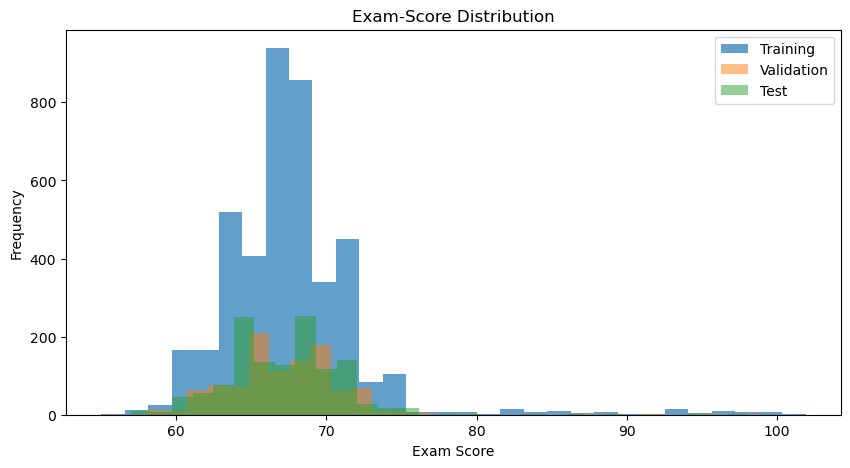

In [336]:
plt.figure(figsize=(10, 5))
plt.hist(y_train_original_data, bins=30, alpha=0.7, label='Training')
plt.hist(y_val_original_data, bins=30, alpha=0.5, label='Validation')
plt.hist(y_test_original_data, bins=30, alpha=0.5, label='Test')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.legend()
plt.title('Exam-Score Distribution')
plt.show()




 Low Grades (<70):
  Count: 960
  MAE: 1.5353
  RMSE: 2.6938

Normal Grades (70-85):
  Count: 324
  MAE: 2.5135
  RMSE: 3.0935

High Grades (>85):
  Count: 5
  MAE: 24.4602
  RMSE: 24.7369


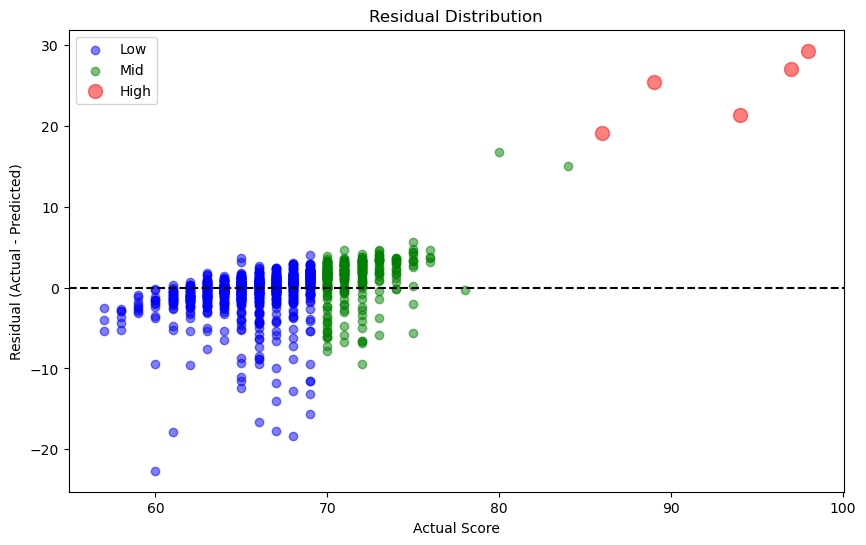

In [337]:
residuals = y_test_original.flatten() - test_pred_original.flatten()

low = (y_test_original.flatten() < 70)
mid = (y_test_original.flatten() >= 70) & (y_test_original.flatten() < 85)
high = (y_test_original.flatten() >= 85)

print(f"\n Low Grades (<70):")
print(f"  Count: {low.sum()}")
print(f"  MAE: {np.abs(residuals[low]).mean():.4f}")
print(f"  RMSE: {np.sqrt((residuals[low]**2).mean()):.4f}")

print(f"\nNormal Grades (70-85):")
print(f"  Count: {mid.sum()}")
print(f"  MAE: {np.abs(residuals[mid]).mean():.4f}")
print(f"  RMSE: {np.sqrt((residuals[mid]**2).mean()):.4f}")

print(f"\nHigh Grades (>85):")
print(f"  Count: {high.sum()}")
print(f"  MAE: {np.abs(residuals[high]).mean():.4f}")
print(f"  RMSE: {np.sqrt((residuals[high]**2).mean()):.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original[low], residuals[low], alpha=0.5, label='Low', c='blue')
plt.scatter(y_test_original[mid], residuals[mid], alpha=0.5, label='Mid', c='green')
plt.scatter(y_test_original[high], residuals[high], alpha=0.5, label='High', c='red', s=100)
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Actual Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.legend()
plt.title('Residual Distribution')
plt.show()